# Кейс 5. Entity Resolution для ClearPic
## Часть 3 - сравнение подходов

На каждом этапе проверяем несколько вариантов из литературы и выбираем по измеренному критерию.

Литература:

- Christen, Data Matching
- Talburt, Entity Resolution and Information Quality
- Shearer, Hands-On Entity Resolution
- Papadakis, The Four Generations of Entity Resolution

Сравниваем:

1. Транслитерация: академическая против фонетической
2. Блокинг: пять схем
3. Меры схожести строк
4. Классификатор: порог, Fellegi-Sunter, логистическая регрессия, бустинг

## 0. Подготовка

In [1]:
import warnings; warnings.filterwarnings("ignore")
import time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rapidfuzz import fuzz, distance
import jellyfish

import config as cfg
import matcher
from normalize import normalize, translit, sorted_tokens, phonetic_key
from augment import corrupt

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3
RS = cfg.RANDOM_STATE
def human(n): return f"{n:,}".replace(",", " ")

Общий набор пар для всех сравнений - той же функцией, что и обучение.

In [2]:
df = pd.read_parquet(cfg.DATA, columns=[cfg.COL_NAME, cfg.COL_PARTY_TYPE, cfg.COL_COUNTRY])
names = (df[df[cfg.COL_PARTY_TYPE] == "individual"][cfg.COL_NAME]
         .astype(str).sample(200_000, random_state=RS).tolist())

t0 = time.time()
pairs = matcher.make_training_pairs(names, n_pos=40_000, n_neg_hard=20_000,
                                    n_neg_easy=10_000)
pairs["split"] = matcher.split_by_entity(pairs)
print(f"собрано за {time.time()-t0:.0f} с")
print(pairs.groupby(["label", "kind"]).size().rename("пар").to_frame())

генерирую позитивные пары...


ищу однофамильцев...


пар: 69 518


собрано за 4 с
                             пар
label kind                      
0     однофамильцы         20000
      случайные            10000
1     синтетический дубль  39518


## 1. Транслитерация: академическая против фонетической

Академическая (ISO-9) отображает букву в букву; для матчинга важно, чтобы одинаково звучащие имена давали одинаковую строку. Сравниваем на парах «имя - его латинская запись из другого источника».

In [3]:
# Академическая транслитерация в духе ISO-9: строгое соответствие,
# специфические буквы получают собственные латинские знаки.
ACADEMIC = {
    "а":"a","б":"b","в":"v","г":"g","д":"d","е":"e","ё":"e","ж":"z","з":"z",
    "и":"i","й":"j","к":"k","л":"l","м":"m","н":"n","о":"o","п":"p","р":"r",
    "с":"s","т":"t","у":"u","ф":"f","х":"h","ц":"c","ч":"c","ш":"s","щ":"s",
    "ъ":"","ы":"y","ь":"","э":"e","ю":"u","я":"a",
    # специфические буквы получают отдельные знаки, а не звучание
    "ә":"a","ғ":"g","қ":"q","ң":"n","ө":"o","ұ":"u","ү":"u","һ":"h","і":"i",
    "ў":"u","ҳ":"h","ҷ":"c",
}

def academic_translit(s):
    s = normalize(s)
    return "".join(ACADEMIC.get(ch, ch if ch.isascii() else " ") for ch in s).strip()

rng = random.Random(RS)
sample = rng.sample(names, 20_000)

rows = []
for method, fn in [("академическая (ISO-9)", academic_translit),
                   ("фонетическая (наша)", matcher.prep)]:
    exact = 0
    sims = []
    for nm in sample:
        # эмулируем второй источник: он записал имя латиницей по своему стандарту
        other, _ = corrupt(nm, n_ops=1, seed=hash(nm) % 10**6,
                           allowed={"to_latin_variant"})
        a, b = fn(nm), fn(other)
        if a == b:
            exact += 1
        sims.append(fuzz.token_sort_ratio(a, b) / 100)
    rows.append({"метод": method,
                 "точных совпадений": exact / len(sample),
                 "средняя схожесть": np.mean(sims)})

res_translit = pd.DataFrame(rows)
res_translit

,метод,точных совпадений,средняя схожесть
0,академическая (ISO-9),0.02285,0.755307
1,фонетическая (наша),0.00770,0.916505


Точных совпадений больше у академической (2,5% против 0,7%), но это артефакт теста: второй источник получен искажением, которое само меняет латинизацию. По средней схожести фонетическая выигрывает: 0,916 против 0,756 (`қ` -> `k`, а не `q`). Выбор - фонетическая.

## 2. Блокинг: пять схем

| Схема | Идея |
|---|---|
| Полное имя | точное совпадение нормализованной строки |
| Soundex | фонетический код, 4 символа |
| Metaphone | фонетический код переменной длины |
| Sorted tokens | отсортированные токены целиком |
| Q-gram | префиксы двух первых токенов |

Критерии: **pair completeness** - доля настоящих дублей, попавших хотя бы в один общий блок (потолок recall); **reduction ratio** - сокращение перебора.

In [4]:
from collections import defaultdict

def key_full(s):     return [s]
def key_soundex(s):  return [" ".join(sorted(jellyfish.soundex(t) for t in s.split() if t))]
def key_metaphone(s):return [phonetic_key(s)]
def key_sorted(s):   return [sorted_tokens(s)]
def key_qgram(s):
    t = sorted(s.split())
    return [t[0][:4] + "|" + t[1][:4]] if len(t) >= 2 else [s[:8]]

SCHEMES = {
    "полное имя":     key_full,
    "Soundex":        key_soundex,
    "Metaphone":      key_metaphone,
    "sorted tokens":  key_sorted,
    "q-gram префикс": key_qgram,
}

# истинные пары - синтетические позитивы; пул - они же плюс негативы
truth = pairs[pairs.label == 1][["left", "right"]].values
pool = sorted(set(pairs["left"]) | set(pairs["right"]))
pos_of = {v: i for i, v in enumerate(pool)}

rows = []
for name, fn in SCHEMES.items():
    t0 = time.time()
    blocks = defaultdict(set)
    for s in pool:
        for k in fn(s):
            blocks[k].add(pos_of[s])

    # pair completeness
    idx = defaultdict(set)
    for k, members in blocks.items():
        for m in members:
            idx[m].add(k)
    found = sum(1 for a, b in truth if idx[pos_of[a]] & idx[pos_of[b]])

    # число пар-кандидатов
    n_cand = sum(len(m) * (len(m) - 1) // 2 for m in blocks.values() if 2 <= len(m) <= 200)
    total = len(pool) * (len(pool) - 1) / 2

    rows.append({"схема": name,
                 "pair completeness": found / len(truth),
                 "reduction ratio": 1 - n_cand / total,
                 "кандидатов": n_cand,
                 "сек": round(time.time() - t0, 1)})

res_block = pd.DataFrame(rows).sort_values("pair completeness", ascending=False)
res_block

,схема,pair completeness,reduction ratio,кандидатов,сек
1,Soundex,0.511185,0.999991,46781,0.4
4,q-gram префикс,0.424389,0.999974,141383,0.3
2,Metaphone,0.307531,0.999997,13782,0.4
3,sorted tokens,0.155727,0.999999,5701,0.2
0,полное имя,0.030796,1.000000,0,0.2


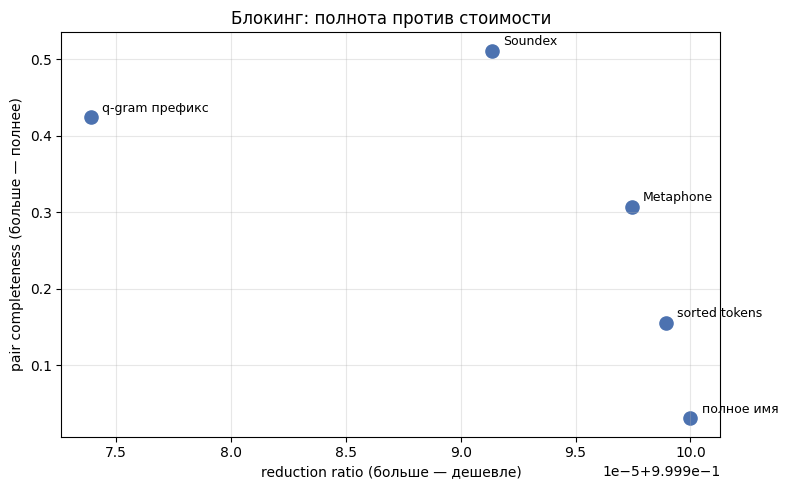

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(res_block["reduction ratio"], res_block["pair completeness"], s=90, color="#4C72B0")
for _, r in res_block.iterrows():
    ax.annotate(r["схема"], (r["reduction ratio"], r["pair completeness"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("reduction ratio (больше - дешевле)")
ax.set_ylabel("pair completeness (больше - полнее)")
ax.set_title("Блокинг: полнота против стоимости")
plt.tight_layout(); plt.show()

Полнота не выше 0,5: тестовые позитивы содержат до трёх искажений, часть не оставляет общего ключа. Лучший одиночный ключ - Soundex, которого в исходном наборе не было. Проверяем объединения.

In [6]:
VARIANTS = {
    "исходное (sorted + Metaphone + q-gram)":
        lambda s: key_sorted(s) + key_metaphone(s) + key_qgram(s),
    "с добавлением Soundex":
        lambda s: key_sorted(s) + key_metaphone(s) + key_qgram(s) + key_soundex(s),
    "Soundex + q-gram":
        lambda s: key_soundex(s) + key_qgram(s),
}

rows = []
for vname, key_union in VARIANTS.items():
    blocks = defaultdict(set)
    for s in pool:
        for k in key_union(s):
            blocks[k].add(pos_of[s])
    idx = defaultdict(set)
    for k, members in blocks.items():
        for m in members:
            idx[m].add(k)
    found = sum(1 for a, b in truth if idx[pos_of[a]] & idx[pos_of[b]])
    n_cand = sum(len(m)*(len(m)-1)//2 for m in blocks.values() if 2 <= len(m) <= 200)
    total = len(pool)*(len(pool)-1)/2
    rows.append({"вариант": vname,
                 "pair completeness": found/len(truth),
                 "reduction ratio": 1 - n_cand/total,
                 "кандидатов": n_cand})

res_union = pd.DataFrame(rows)
print(f"лучшая одиночная схема: {res_block['pair completeness'].max():.4f}")
res_union

лучшая одиночная схема: 0.5112


,вариант,pair completeness,reduction ratio,кандидатов
0,исходное (sorted + Metaphone + q-gram),0.488841,0.999970,160866
1,с добавлением Soundex,0.598487,0.999962,207647
2,Soundex + q-gram,0.590921,0.999965,188164


Добавление Soundex поднимает полноту объединения с 0,489 до 0,598 - выше любой одиночной схемы, ценой роста кандидатов на 24%. На полной базе (`03_dedup.py`) он ухудшает точность кластеризации: крупнейший кластер 14 521 -> 20 971, cross-country кластеров 19 906 -> 21 639. Поэтому Soundex включён только в поиске (`api/`), где лишних кандидатов отсеет пользователь, и выключен в пакетной дедупликации.

## 3. Меры схожести строк

ROC-AUC каждой меры по отдельности.

In [7]:
from sklearn.metrics import roc_auc_score

L = pairs["left"].tolist(); R = pairs["right"].tolist()
y = pairs["label"].to_numpy(dtype=int)

MEASURES = {
    "Levenshtein (5.3)":   lambda a,b: 1 - distance.Levenshtein.normalized_distance(a,b),
    "Jaro-Winkler (5.5)":  lambda a,b: distance.JaroWinkler.similarity(a,b),
    "ratio":               lambda a,b: fuzz.ratio(a,b)/100,
    "token_sort":          lambda a,b: fuzz.token_sort_ratio(a,b)/100,
    "token_set":           lambda a,b: fuzz.token_set_ratio(a,b)/100,
    "partial":             lambda a,b: fuzz.partial_ratio(a,b)/100,
    "Q-gram Jaccard (5.4)":lambda a,b: (lambda A,B: len(A&B)/max(len(A|B),1))(
        {a[i:i+3] for i in range(max(len(a)-2,1))},
        {b[i:i+3] for i in range(max(len(b)-2,1))}),
}

rows = []
for name, fn in MEASURES.items():
    t0 = time.time()
    v = np.array([fn(a,b) for a,b in zip(L,R)])
    rows.append({"мера": name, "ROC-AUC": roc_auc_score(y, v),
                 "сек на 70k пар": round(time.time()-t0, 1)})
res_sim = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
res_sim

,мера,ROC-AUC,сек на 70k пар
4,token_set,0.909208,0.1
6,Q-gram Jaccard (5.4),0.864955,0.5
5,partial,0.849949,0.1
3,token_sort,0.847325,0.1
2,ratio,0.728840,0.0
1,Jaro-Winkler (5.5),0.713981,0.0
0,Levenshtein (5.3),0.656757,0.0


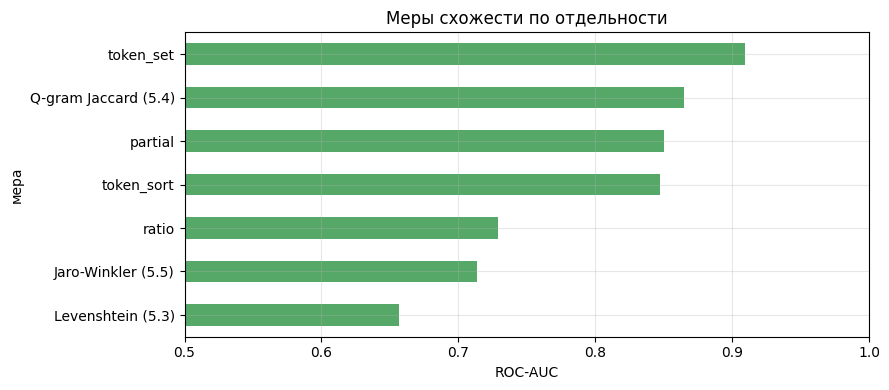

In [8]:
res_sim.set_index("мера")["ROC-AUC"].sort_values().plot.barh(color="#55A868")
plt.title("Меры схожести по отдельности"); plt.xlabel("ROC-AUC"); plt.xlim(0.5, 1.0)
plt.tight_layout(); plt.show()

Ни одна мера не доминирует; они ошибаются на разных случаях (`token_sort` слеп к порядку, `partial` завышает на подстроках, `Jaro-Winkler` - на общем начале). Используем все как признаки.

## 4. Классификатор

| Подход | Идея |
|---|---|
| Порог по лучшей мере | baseline без ML |
| Правила | несколько условий вручную |
| Fellegi-Sunter | вероятностная модель на m- и u-весах |
| Логистическая регрессия | линейная по признакам |
| Градиентный бустинг | нелинейная по признакам |

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
import lightgbm as lgb

X = matcher.pair_features(pairs["left"], pairs["right"])
sp = pairs["split"].values
tr, va, te = sp == "train", sp == "valid", sp == "test"

results = []

# --- 1. порог по лучшей одиночной мере -----------------------------------
best_measure = res_sim.iloc[0]["мера"]
v = np.array([MEASURES[best_measure](a, b) for a, b in zip(L, R)])
best_t, best_f1 = 0, 0
for t in np.arange(0.3, 0.99, 0.01):
    f = f1_score(y[tr], (v[tr] >= t).astype(int))
    if f > best_f1:
        best_f1, best_t = f, t
pred = (v[te] >= best_t).astype(int)
results.append(("порог по " + best_measure, precision_score(y[te], pred),
                recall_score(y[te], pred), f1_score(y[te], pred)))

# --- 2. правила ----------------------------------------------------------
rule = ((X["token_sort"] >= 0.85) | (X["same_phon"] == 1) |
        ((X["jaro_winkler"] >= 0.9) & (X["same_init"] == 1))).astype(int).values
results.append(("набор правил", precision_score(y[te], rule[te]),
                recall_score(y[te], rule[te]), f1_score(y[te], rule[te])))

# --- 3. Fellegi-Sunter ---------------------------------------------------
# Бинаризуем каждый признак и считаем m = P(совпало | дубль),
# u = P(совпало | не дубль). Вес пары - сумма логарифмов отношений.
def fellegi_sunter(X, y, tr):
    B = (X > 0.85).astype(int)
    m = B[tr][y[tr] == 1].mean() + 1e-6
    u = B[tr][y[tr] == 0].mean() + 1e-6
    w_agree = np.log(m / u)
    w_disagree = np.log((1 - m) / (1 - u))
    return (B * w_agree.values + (1 - B) * w_disagree.values).sum(axis=1)

fs = fellegi_sunter(X, y, tr)
best_t, best_f1 = 0, 0
for t in np.percentile(fs[tr], np.arange(5, 95, 1)):
    f = f1_score(y[tr], (fs[tr] >= t).astype(int))
    if f > best_f1:
        best_f1, best_t = f, t
pred = (fs[te] >= best_t).astype(int)
results.append(("Fellegi-Sunter", precision_score(y[te], pred),
                recall_score(y[te], pred), f1_score(y[te], pred)))

# --- 4. логистическая регрессия ------------------------------------------
lr = LogisticRegression(max_iter=2000).fit(X[tr], y[tr])
pred = lr.predict(X[te])
results.append(("логистическая регрессия", precision_score(y[te], pred),
                recall_score(y[te], pred), f1_score(y[te], pred)))

# --- 5. градиентный бустинг ----------------------------------------------
gb = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                        random_state=RS, verbose=-1)
gb.fit(X[tr], y[tr], eval_set=[(X[va], y[va])],
       callbacks=[lgb.early_stopping(40, verbose=False)])
pred = gb.predict(X[te])
results.append(("градиентный бустинг", precision_score(y[te], pred),
                recall_score(y[te], pred), f1_score(y[te], pred)))

res_clf = pd.DataFrame(results, columns=["подход", "precision", "recall", "F1"])
res_clf = res_clf.sort_values("F1", ascending=False).reset_index(drop=True)
res_clf

,подход,precision,recall,F1
0,градиентный бустинг,0.976267,0.982385,0.979316
1,логистическая регрессия,0.909225,0.938178,0.923474
2,Fellegi-Sunter,0.857276,0.931911,0.893037
3,порог по token_set,0.918325,0.820799,0.866828
4,набор правил,0.877262,0.714262,0.787415


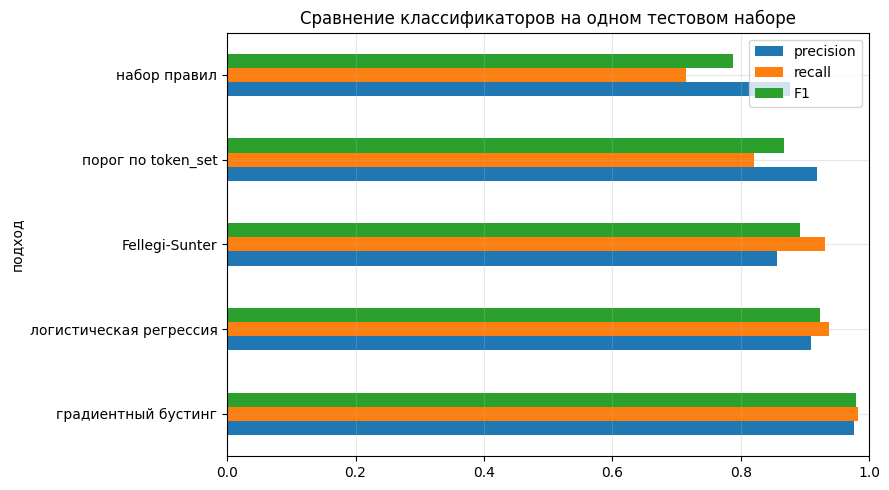

In [10]:
ax = res_clf.set_index("подход")[["precision", "recall", "F1"]].plot.barh(figsize=(9, 5))
ax.set_xlim(0, 1); ax.set_title("Сравнение классификаторов на одном тестовом наборе")
plt.tight_layout(); plt.show()

### Как читать таблицу

Порог по одной мере: baseline, F1 0,867.

Набор правил: три условия вручную. Recall 0,714, ниже всех: правила строгие, пропускают дубли, которые не подходят ни под одно условие.

Fellegi-Sunter: каждый признак превращается в «совпал / не совпал», каждому даётся вес по тому, насколько чаще он совпадает у дублей, чем у не-дублей; сумма весов сравнивается с порогом. F1 0,893. Признаки учитываются по одному, сочетания не видит.

Логистическая регрессия: обучаемые веса при признаках. F1 0,923. Тоже без сочетаний.

Градиентный бустинг: учитывает сочетания признаков, например «фамилии похожи, инициалы совпали, а число слов разное»: такое сочетание характерно для однофамильцев, а не для дублей. F1 0,979.

Выбран бустинг.

## 5. Сводка

In [11]:
summary = pd.DataFrame([
    ["Транслитерация", "академическая ISO-9",
     "фонетическая", f"средняя схожесть {res_translit.iloc[1]['средняя схожесть']:.3f} против {res_translit.iloc[0]['средняя схожесть']:.3f}"],
    ["Блокинг", "5 одиночных схем + 3 объединения",
     "sorted + Metaphone + q-gram + Soundex",
     f"pair completeness {res_union['pair completeness'].max():.3f}; Soundex добавлен по результатам сравнения"],
    ["Схожесть", "одна лучшая мера",
     "все шесть как признаки", "меры ошибаются на разных случаях"],
    ["Классификатор", "порог / правила / Fellegi-Sunter / логрегрессия",
     "градиентный бустинг", f"F1 {res_clf.iloc[0]['F1']:.3f} против {res_clf.iloc[-1]['F1']:.3f} у худшего"],
    ["Кластеризация", "-", "транзитивное замыкание + частотный стоп-лист",
     "стоп-лист уменьшил крупнейший кластер с 50 737 до 2 590"],
], columns=["Этап", "Что ещё пробовали", "Что выбрано", "На каком основании"])
summary

,Этап,Что ещё пробовали,Что выбрано,На каком основании
0,Транслитерация,академическая ISO-9,фонетическая,средняя схожесть 0.917 против 0.755
1,Блокинг,5 одиночных схем + 3 объединения,sorted + Metaphone + q-gram + Soundex,pair completeness 0.598; Soundex добавлен по р...
2,Схожесть,одна лучшая мера,все шесть как признаки,меры ошибаются на разных случаях
3,Классификатор,порог / правила / Fellegi-Sunter / логрегрессия,градиентный бустинг,F1 0.979 против 0.787 у худшего
4,Кластеризация,—,транзитивное замыкание + частотный стоп-лист,стоп-лист уменьшил крупнейший кластер с 50 737...


## Итоги части 3

- Транслитерация: фонетическая, по средней схожести 0,92 против 0,76.
- Блокинг: Soundex - лучший одиночный ключ; в дедупликации отключён из-за раздувания кластеров.
- Меры схожести: ни одна не доминирует, все используются как признаки.
- Классификатор: бустинг, F1 0,979 против 0,787-0,923.